# 2 &middot; Deformation Gradient Intuition

Now that we know \(F = D_s D_m^{-1}\) (tutorial 1), let's *feel* it. We apply the
four basic deformations &mdash; **translation, rotation, scale, shear** &mdash; to
a triangle and read off \(F\) each time.

Watch for the headline fact: **\(F\) ignores translation.** A gradient kills
additive constants, so sliding the triangle around leaves \(F = I\).

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
import utils
os.makedirs("media", exist_ok=True)

## The rest triangle and four deformation maps

Each map is a linear transform of the rest vertices (translation also adds an
offset). We read \(F\) back with `simkit.deformation_gradient`.

In [2]:
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T = np.array([[0, 1, 2]])

def translate(X, t):     return X + np.asarray(t, float)
def rotate(X, theta):
    c, s = np.cos(theta), np.sin(theta)
    return X @ np.array([[c, -s], [s, c]]).T
def scale(X, sx, sy=None):
    sy = sx if sy is None else sy
    return X * np.array([sx, sy])
def shear(X, k):         return X @ np.array([[1.0, k], [0.0, 1.0]]).T

def F_of(U):             return simkit.deformation_gradient(X, T, U)[0]

## Translation leaves \(F = I\)

Slide the triangle anywhere; \(F\) stays the identity.

In [3]:
for offset in ([0.0, 0.0], [2.0, -1.5], [-3.0, 4.0]):
    F = F_of(translate(X, offset))
    print(f"translate by {offset}:  F =\n{np.round(F, 3)}   det F = {np.linalg.det(F):.3f}\n")

translate by [0.0, 0.0]:  F =
[[1. 0.]
 [0. 1.]]   det F = 1.000

translate by [2.0, -1.5]:  F =
[[1. 0.]
 [0. 1.]]   det F = 1.000

translate by [-3.0, 4.0]:  F =
[[ 1. -0.]
 [ 0.  1.]]   det F = 1.000



## The four deformations side by side

Rotation gives a pure rotation (\(\det F = 1\)); scale gives a diagonal \(F\);
shear gives an off-diagonal term; translation &mdash; even with a big offset
&mdash; gives \(F = I\).

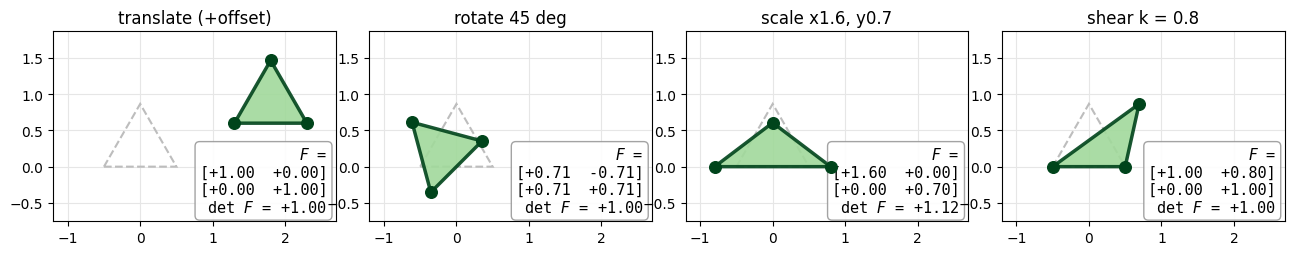

In [4]:
cases = [
    ("translate (+offset)", translate(X, [1.8, 0.6])),
    ("rotate 45 deg",        rotate(X, np.pi / 4)),
    ("scale x1.6, y0.7",     scale(X, 1.6, 0.7)),
    ("shear k = 0.8",        shear(X, 0.8)),
]
cases = [(name, U, F_of(U)) for name, U in cases]
fig, _ = utils.deformation_panels(cases, rest=X)
plt.show()

## Animation: rotating the triangle &mdash; \(F\) traces \(R(\theta)\)


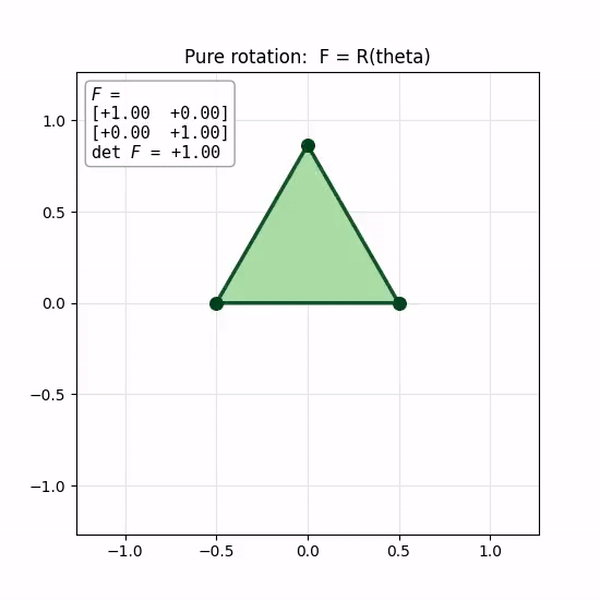

In [5]:
angles = np.linspace(0, 2 * np.pi, 48, endpoint=False)
states = [rotate(X, a) for a in angles]
Fs = [F_of(U) for U in states]
fig, anim = utils.animate_deformation(states, Fs, rest=X, fps=20,
                                      title="Pure rotation:  F = R(theta)")
utils.save_anim(anim, "media/02_rotation.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Animation: translating the triangle &mdash; \(F = I\) always


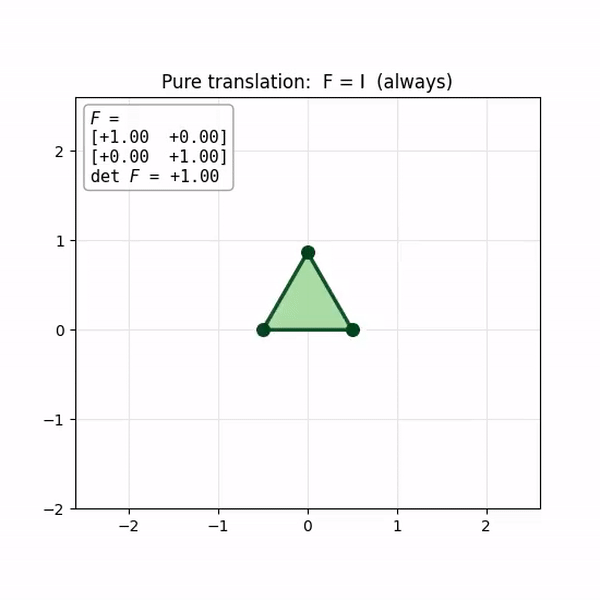

In [6]:
ts = np.linspace(0, 2 * np.pi, 48)
path = np.stack([1.6 * np.sin(ts), 1.0 * np.sin(2 * ts)], axis=1)   # figure-8
states = [translate(X, p) for p in path]
Fs = [F_of(U) for U in states]
fig, anim = utils.animate_deformation(states, Fs, rest=X,
                                      lims=((-2.6, 2.6), (-2.0, 2.6)), fps=20,
                                      title="Pure translation:  F = I  (always)")
utils.save_anim(anim, "media/02_translation.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

### Takeaways
* \(F\) is the local gradient, so it is **blind to translation**.
* Rotation &rarr; rotation matrix; scale &amp; shear show up directly in \(F\).

Next: turn \(F\) into a single number measuring *how deformed* a shape is &mdash;
the **elastic energy**.